# Case Study: Cyclistic Bike-Share Analysis

## 1. Ask (Preguntar)

**Business Task:** Analizar los datos históricos de viajes de Cyclistic (2019 Q1 y 2020 Q1) para identificar cómo difiere el comportamiento de uso entre ciclistas con membresía anual (members) y ciclistas ocasionales (casual), con el fin de generar insights que sustenten el diseño de una estrategia de marketing orientada a convertir ciclistas ocasionales en miembros anuales.

**Pregunta guía:** ¿Cómo usan los ciclistas anuales (members) y los ciclistas 
ocasionales (casual) las bicicletas de Cyclistic de manera diferente?

**Stakeholders:**
- Lily Moreno — Directora de Marketing
- Equipo de análisis de marketing
- Equipo ejecutivo de Cyclistic

**¿Cómo ayudan estos insights al negocio?** 
Entender las diferencias de uso entre members y casual riders permite diseñar mensajes de marketing dirigidos a las motivaciones reales de cada segmento (en lugar de campañas genéricas). Si identificamos, por ejemplo, en qué días, horarios, duración de viaje o tipo de bicicleta difieren ambos grupos, el equipo de marketing puede diseñar promociones específicas (p. ej. incentivos de fin de semana, descuentos por viajes cortos frecuentes, o campañas dirigidas a usuarios que ya muestran patrones "casi member") que aumenten la probabilidad de conversión, optimizando el presupuesto de marketing en lugar de dispersarlo en audiencias no segmentadas.

## 2. Prepare (Preparar)

**Fuente de datos:** Divvy Trip Data (2019 Q1 y 2020 Q1), datos públicos 
proporcionados por Motivate International Inc. bajo licencia de datos de Divvy.

**Evaluación ROCCC:**
- **Reliable (Confiable):** Datos originales de la operadora del sistema, sin manipulación de terceros.
- **Original:** Fuente primaria (Divvy/Motivate International).
- **Comprehensive (Completo):** Incluye fecha/hora de inicio y fin, estación de origen/destino, tipo de bicicleta (o duración de viaje) y tipo de usuario (member/casual).
- **Current (Actual):** Se usan los datos de 2019-Q1 y 2020-Q1 disponibles según el script guía del case study; en un entorno real, se usarían los últimos 12 meses.
- **Cited (Citado):** Fuente y licencia documentadas (Motivate International Inc., Divvy Data License Agreement).

**Limitaciones conocidas:**
- No es posible vincular los viajes a información personal identificable (PII), por lo tanto no se puede determinar si un mismo usuario casual compró varios pases individuales.
- Los esquemas de columnas de 2019 y 2020 son diferentes (2020 no incluye `tripduration` ni `gender`/`birthyear`), lo cual deberá resolverse en la fase de limpieza.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os



# Cargar los dos datasets
q1_2019 = pd.read_csv('Divvy_Trips_2019_Q1.csv')
q1_2020 = pd.read_csv('Divvy_Trips_2020_Q1.csv')

# Primer vistazo
print("Columnas 2019 Q1:", q1_2019.columns.tolist())
print("Columnas 2020 Q1:", q1_2020.columns.tolist())
print("\nForma 2019 Q1:", q1_2019.shape)
print("Forma 2020 Q1:", q1_2020.shape)

Columnas 2019 Q1: ['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration', 'from_station_id', 'from_station_name', 'to_station_id', 'to_station_name', 'usertype', 'gender', 'birthyear']
Columnas 2020 Q1: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

Forma 2019 Q1: (365069, 12)
Forma 2020 Q1: (426887, 13)


### Decisiones a tomar 
1. Eliminar gender y birthyear de 2019 → el dataset de 2020 no los tiene, y además el caso de estudio nos advierte que no debemos usar información que pudiera acercarse a PII. Para mantener consistencia, se descartan.
2. Eliminar tripduration de 2019 → en vez de usarla, vamos a calcular ride_length desde cero en ambos datasets (como indica el roadmap), así el cálculo es consistente y no dependemos de un campo preexistente.
3. Eliminar lat/lng de 2020 → no existen en 2019, y no son necesarias para responder la pregunta de negocio.
4. Renombrar columnas de 2019 para que coincidan con los nombres de 2020 (el esquema más "moderno").
5. Mapear valores de usertype: Subscriber → member, Customer → casual.

# 3. Process (Procesar) 

Paso 1. Estandarizar nombres de columnas en 2019

In [11]:
# Recargar el dataset original desde cero para evitar arrastrar estados previos
q1_2019 = pd.read_csv('Divvy_Trips_2019_Q1.csv')

# Confirmar que las columnas originales están ahí
print(q1_2019.columns.tolist())
q1_2019 = q1_2019.rename(columns={
    'trip_id': 'ride_id',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'bikeid': 'rideable_type',
    'from_station_id': 'start_station_id',
    'from_station_name': 'start_station_name',
    'to_station_id': 'end_station_id',
    'to_station_name': 'end_station_name',
    'usertype': 'member_casual'
})

# Eliminamos columnas que no usaremos o no existen en 2020
q1_2019 = q1_2019.drop(columns=['tripduration', 'gender', 'birthyear'], errors = 'ignore' )

['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration', 'from_station_id', 'from_station_name', 'to_station_id', 'to_station_name', 'usertype', 'gender', 'birthyear']


Paso 2. Eliminar columnas de 2020 que no existen en 2019

In [13]:
q1_2020 = q1_2020.drop(columns=['start_lat', 'start_lng', 'end_lat', 'end_lng'])

Paso 3. Verificar que ambos esquemas ya coincidan

In [14]:
print("2019 Q1:", sorted(q1_2019.columns.tolist()))
print("2020 Q1:", sorted(q1_2020.columns.tolist()))
print(set(q1_2019.columns) == set(q1_2020.columns))  # debe imprimir True

2019 Q1: ['end_station_id', 'end_station_name', 'ended_at', 'member_casual', 'ride_id', 'rideable_type', 'start_station_id', 'start_station_name', 'started_at']
2020 Q1: ['end_station_id', 'end_station_name', 'ended_at', 'member_casual', 'ride_id', 'rideable_type', 'start_station_id', 'start_station_name', 'started_at']
True


Paso 4. Estandarizar los valores de member_casual en 2019

In [15]:
print(q1_2019['member_casual'].unique())  # confirmar valores antes de mapear

q1_2019['member_casual'] = q1_2019['member_casual'].map({
    'Subscriber': 'member',
    'Customer': 'casual'
})

['Subscriber' 'Customer']


Paso 5. Unir (concatenar) ambos dataframes

In [16]:
all_trips = pd.concat([q1_2019, q1_2020], ignore_index=True)

print(all_trips.shape)
print(all_trips['member_casual'].unique())  # debe mostrar solo ['member', 'casual']
all_trips.head()

(791956, 9)
['member' 'casual']


,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,199,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,member
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,44,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),member
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,15,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),member
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,123,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,member
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,173,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,member


Paso 6. Convertir fechas a formato datetime

In [17]:
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'])

print(all_trips.dtypes[['started_at', 'ended_at']])

started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object


Paso 7. Calcular ride_length (duración del viaje)

In [18]:
all_trips['ride_length'] = (all_trips['ended_at'] - all_trips['started_at']).dt.total_seconds() / 60

all_trips['ride_length'].describe()

count    791956.000000
mean         19.730221
std         553.545687
min          -9.200000
25%           5.466667
50%           8.950000
75%          15.166667
max      177200.366667
Name: ride_length, dtype: float64

Paso 8. Calcular day_of_week

In [19]:
# day_of_week: 1 = Domingo, 7 = Sábado (igual que el roadmap original con WEEKDAY)
all_trips['day_of_week'] = all_trips['started_at'].dt.dayofweek.apply(lambda x: (x + 2) if x < 6 else 1)

# Verificación rápida: nombre del día para chequeo visual
all_trips['day_name'] = all_trips['started_at'].dt.day_name()
print(all_trips[['started_at', 'day_of_week', 'day_name']].head(10))

           started_at  day_of_week day_name
0 2019-01-01 00:04:37            3  Tuesday
1 2019-01-01 00:08:13            3  Tuesday
2 2019-01-01 00:13:23            3  Tuesday
3 2019-01-01 00:13:45            3  Tuesday
4 2019-01-01 00:14:52            3  Tuesday
5 2019-01-01 00:15:33            3  Tuesday
6 2019-01-01 00:16:06            3  Tuesday
7 2019-01-01 00:18:41            3  Tuesday
8 2019-01-01 00:18:43            3  Tuesday
9 2019-01-01 00:19:18            3  Tuesday


Paso 9. Revisar calidad de los datos (errores, nulos, duplicados)

In [21]:
# Nulos
print("Valores nulos por columna:\n", all_trips.isnull().sum())

# Duplicados en ride_id
print("\nride_id duplicados:", all_trips['ride_id'].duplicated().sum())

# Estadística de ride_length para detectar valores negativos o absurdos
print("\nEstadísticas de ride_length (minutos):")
print(all_trips['ride_length'].describe())

# ¿Cuántos viajes con duración negativa o cero?
print("\nViajes con duración <= 0:", (all_trips['ride_length'] <= 0).sum())

# ¿Estaciones relacionadas con mantenimiento (HQ QR / testing)?
print("\nViajes desde estación 'HQ QR':", 
      all_trips['start_station_name'].str.contains('HQ QR', case=False, na=False).sum())

Valores nulos por columna:
 ride_id               0
started_at            0
ended_at              0
rideable_type         0
start_station_id      0
start_station_name    0
end_station_id        1
end_station_name      1
member_casual         0
ride_length           0
day_of_week           0
day_name              0
dtype: int64

ride_id duplicados: 0

Estadísticas de ride_length (minutos):
count    791956.000000
mean         19.730221
std         553.545687
min          -9.200000
25%           5.466667
50%           8.950000
75%          15.166667
max      177200.366667
Name: ride_length, dtype: float64

Viajes con duración <= 0: 210

Viajes desde estación 'HQ QR': 3767


Paso 10. Limpiar el dataset (crear all_trips_clean)

In [22]:
# Partimos de una copia para no perder el dataframe original con datos "crudos combinados"
all_trips_clean = all_trips.copy()

# Filtro 1: eliminar viajes con duración <= 0
all_trips_clean = all_trips_clean[all_trips_clean['ride_length'] > 0]

# Filtro 2: eliminar viajes de estaciones de mantenimiento (HQ QR)
all_trips_clean = all_trips_clean[
    ~all_trips_clean['start_station_name'].str.contains('HQ QR', case=False, na=False)
]

# Filtro 3: eliminar la(s) fila(s) con estación de destino nula
all_trips_clean = all_trips_clean.dropna(subset=['end_station_id', 'end_station_name'])

# Verificación de forma final
print("Filas antes de limpiar:", all_trips.shape[0])
print("Filas después de limpiar:", all_trips_clean.shape[0])
print("Filas eliminadas:", all_trips.shape[0] - all_trips_clean.shape[0])

# Revisar estadísticas de ride_length después de limpiar
print("\nEstadísticas de ride_length limpio (minutos):")
print(all_trips_clean['ride_length'].describe())

Filas antes de limpiar: 791956
Filas después de limpiar: 788189
Filas eliminadas: 3767

Estadísticas de ride_length limpio (minutos):
count    788189.000000
mean         19.824311
std         554.865218
min           0.016667
25%           5.516667
50%           8.983333
75%          15.200000
max      177200.366667
Name: ride_length, dtype: float64


Paso 11. Investigar outliers extremos de duración

In [23]:
# Ver percentiles altos para entender la distribución de la cola
print(all_trips_clean['ride_length'].quantile([0.90, 0.95, 0.99, 0.999, 0.9999]))

# ¿Cuántos viajes duran más de 24 horas (1440 min)?
print("\nViajes > 24 horas:", (all_trips_clean['ride_length'] > 1440).sum())

# ¿Cuántos viajes duran más de 12 horas (720 min)?
print("Viajes > 12 horas:", (all_trips_clean['ride_length'] > 720).sum())

# Revisar algunos de los viajes más largos
print("\nTop 10 viajes más largos:")
print(all_trips_clean.nlargest(10, 'ride_length')[['ride_id', 'started_at', 'ended_at', 'ride_length', 'member_casual', 'start_station_name']])

0.9000       25.350000
0.9500       33.800000
0.9900       77.350000
0.9990      894.532200
0.9999    12656.629953
Name: ride_length, dtype: float64

Viajes > 24 horas: 482
Viajes > 12 horas: 897

Top 10 viajes más largos:
                 ride_id          started_at            ended_at  \
148897          21920842 2019-02-14 14:44:13 2019-06-17 16:04:35   
421464  279F7DB076FD4444 2020-01-09 21:00:22 2020-04-27 12:30:46   
626364  377B59F0A27BB4CB 2020-02-02 17:18:57 2020-05-12 16:15:42   
525263  ABA59A8FED82A85C 2020-02-28 08:47:09 2020-05-19 20:10:34   
246297          22039457 2019-03-12 18:48:41 2019-05-22 08:15:49   
88324           21845123 2019-01-21 23:07:19 2019-03-28 08:30:17   
725594  F4555B8C917E55D3 2020-03-02 17:57:47 2020-05-06 21:11:18   
470307  63F1D0FB38E8B158 2020-01-26 10:24:05 2020-03-28 22:15:51   
593568  B02926396CBED16D 2020-02-09 10:23:26 2020-04-11 18:46:05   
128296          21894590 2019-02-07 16:54:32 2019-04-04 23:45:40   

          ride_length member

Paso 12. Filtro final y creación del dataset limpio definitivo

In [25]:
all_trips_clean = all_trips_clean[all_trips_clean['ride_length'] <= 1440]

print("Filas finales:", all_trips_clean.shape[0])
print("\nEstadísticas finales de ride_length (minutos):")
print(all_trips_clean['ride_length'].describe())

Filas finales: 787707

Estadísticas finales de ride_length (minutos):
count    787707.000000
mean         13.723390
std          31.111472
min           0.016667
25%           5.500000
50%           8.983333
75%          15.183333
max        1435.916667
Name: ride_length, dtype: float64


## 3. Process (Procesar) — Resumen de limpieza

**Herramienta usada:** Python (Pandas), por su capacidad de manejar datasets grandes 
(~790K filas) de forma eficiente y reproducible, además de facilitar la documentación 
del proceso en un notebook.

**Pasos de limpieza y transformación:**
1. Estandarización de nombres de columnas entre 2019 Q1 (esquema antiguo) y 2020 Q1 
   (esquema nuevo) para permitir su unión.
2. Eliminación de columnas no comparables entre ambos años (`gender`, `birthyear`, 
   `tripduration` de 2019; coordenadas lat/lng de 2020) — no esenciales para responder 
   la pregunta de negocio.
3. Estandarización de valores de usuario: `Subscriber`→`member`, `Customer`→`casual`.
4. Unión (concat) de ambos datasets en `all_trips` (791,956 filas).
5. Conversión de fechas a formato datetime y cálculo de `ride_length` (minutos) y 
   `day_of_week` (1=Domingo, 7=Sábado), siguiendo el roadmap del caso de estudio.
6. **Eliminación de 3,767 viajes** originados en estaciones "HQ QR" — corresponden a 
   viajes de control de calidad/mantenimiento de Divvy, no a usuarios reales. Estos 
   mismos registros concentraban los viajes con duración negativa o cero.
7. **Eliminación de 482 viajes con duración mayor a 24 horas** — corresponden a 
   bicicletas no devueltas correctamente (perdidas/robadas), no a patrones de uso reales; 
   representan <0.1% de los datos.
8. Eliminación de 1 fila con estación de destino nula.

**Dataset final:** `all_trips_clean`, [PON AQUÍ EL NÚMERO FINAL DE FILAS] filas listas para análisis.

**Nota metodológica:** Dada la alta dispersión (`std`) incluso después de la limpieza, 
se dará prioridad a la **mediana** sobre la media en las comparaciones de duración de 
viaje, ya que es más robusta ante outliers residuales.

# Fase 4: ANALYZE (Analizar)

Aquí empezamos a responder directamente la pregunta de negocio: ¿cómo difiere el uso entre members y casual riders?

Paso 1. Comparación general: conteo y duración por tipo de usuario

In [26]:
# ¿Cuántos viajes hace cada grupo, y cuál es su duración típica?
summary_by_type = all_trips_clean.groupby('member_casual')['ride_length'].agg(
    num_rides='count',
    mean_length='mean',
    median_length='median',
    max_length='max',
    std_length='std'
)
print(summary_by_type)

               num_rides  mean_length  median_length   max_length  std_length
member_casual                                                                
casual             67582    38.378880      23.133333  1435.916667   76.327630
member            720125    11.409532       8.466667  1433.066667   21.204191


Paso 2. Duración promedio y mediana por día de la semana

In [27]:
# Duración por día de la semana, separado por tipo de usuario
by_day = all_trips_clean.groupby(['member_casual', 'day_of_week'])['ride_length'].agg(
    num_rides='count',
    mean_length='mean',
    median_length='median'
).reset_index()

print(by_day)

   member_casual  day_of_week  num_rides  mean_length  median_length
0         casual            1      18578    40.857169      26.683333
1         casual            2       5569    34.426486      19.833333
2         casual            3       7288    35.563465      19.600000
3         casual            4       7655    41.116743      23.683333
4         casual            5       7105    35.271410      20.100000
5         casual            6       7971    37.124838      19.850000
6         casual            7      13416    38.945682      24.116667
7         member            1      60178    12.920790       9.133333
8         member            2     110412    11.104777       8.383333
9         member            3     127946    11.323816       8.483333
10        member            4     121878    11.170365       8.450000
11        member            5     125198    11.069124       8.366667
12        member            6     115132    11.101253       8.200000
13        member            7     

Paso 3. Número de viajes por día de la semana (tabla pivote, como sugiere el roadmap)

In [28]:
rides_by_day_pivot = all_trips_clean.pivot_table(
    index='day_of_week',
    columns='member_casual',
    values='ride_id',
    aggfunc='count'
)
print(rides_by_day_pivot)

# Duración promedio también en formato pivote (fácil de graficar después)
avg_duration_pivot = all_trips_clean.pivot_table(
    index='day_of_week',
    columns='member_casual',
    values='ride_length',
    aggfunc='mean'
)
print("\n", avg_duration_pivot)

member_casual  casual  member
day_of_week                  
1               18578   60178
2                5569  110412
3                7288  127946
4                7655  121878
5                7105  125198
6                7971  115132
7               13416   59381

 member_casual     casual     member
day_of_week                        
1              40.857169  12.920790
2              34.426486  11.104777
3              35.563465  11.323816
4              41.116743  11.170365
5              35.271410  11.069124
6              37.124838  11.101253
7              38.945682  12.435637


Paso 4. Patrón por hora del día (nos falta esta dimensión, y suele ser muy reveladora)

In [29]:
all_trips_clean['hour'] = all_trips_clean['started_at'].dt.hour

rides_by_hour = all_trips_clean.pivot_table(
    index='hour',
    columns='member_casual',
    values='ride_id',
    aggfunc='count'
)
print(rides_by_hour)

member_casual  casual  member
hour                         
0                 460    2956
1                 328    1740
2                 240    1129
3                 143     896
4                  91    1984
5                 194    9040
6                 482   27697
7                1010   58611
8                1828   78695
9                1862   35996
10               2776   24268
11               4236   29284
12               5616   33544
13               7166   33015
14               7689   32173
15               7783   43011
16               7608   76338
17               6963   95842
18               4248   55544
19               2460   32561
20               1529   19213
21               1294   13617
22                932    8287
23                644    4684


Paso 5. Tipo de bicicleta más usada por grupo (con la advertencia que discutimos antes)

In [30]:
rides_2020_only = all_trips_clean[all_trips_clean['started_at'].dt.year == 2020]
bike_type_summary = rides_2020_only.groupby(['member_casual', 'rideable_type'])['ride_id'].count().unstack()
print(bike_type_summary)

rideable_type  docked_bike
member_casual             
casual               44487
member              378343


Paso 6. Documentar el resumen del análisis (Markdown)

## 4. Analyze (Analizar) — Resumen de hallazgos

1. **Duración de viaje:** los casual riders tienen una mediana de duración de 23.1 min, 
   ~2.7 veces mayor que los members (8.5 min).
2. **Volumen de viajes:** los members concentran el 91% de los viajes (720,125 de 787,707), 
   pero con trayectos breves y consistentes.
3. **Patrón semanal:** los casual riders concentran su actividad los fines de semana; los 
   members mantienen un volumen alto y estable de lunes a viernes.
4. **Patrón horario:** los members muestran dos picos claros (7-9h y 16-18h), consistentes 
   con desplazamientos al trabajo. Los casual riders muestran un único pico amplio en la 
   tarde (15-17h), consistente con uso recreativo.
5. **Tipo de bicicleta:** en el subconjunto 2020, el 100% de los registros corresponden a 
   `docked_bike`; no hay variación para comparar esta variable con los datos disponibles 
   (limitación a documentar).

**Conclusión preliminar:** los datos muestran patrones de uso claramente distintos: los 
members usan Cyclistic como medio de transporte funcional (commute), mientras que los 
casual riders lo usan predominantemente como actividad de ocio, especialmente en fin de 
semana y horas de la tarde.

# Fase 5: SHARE (Compartir) — Visualizaciones

Ahora convertimos estas tablas en gráficas profesionales. Vamos a usar matplotlib + seaborn (más pulido visualmente que matplotlib solo).

In [32]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Diccionario para mostrar nombres de días en vez de números en las gráficas
day_names = {1: 'Dom', 2: 'Lun', 3: 'Mar', 4: 'Mié', 5: 'Jue', 6: 'Vie', 7: 'Sáb'}

Paso 2. Gráfica 1: Número de viajes por día de la semana

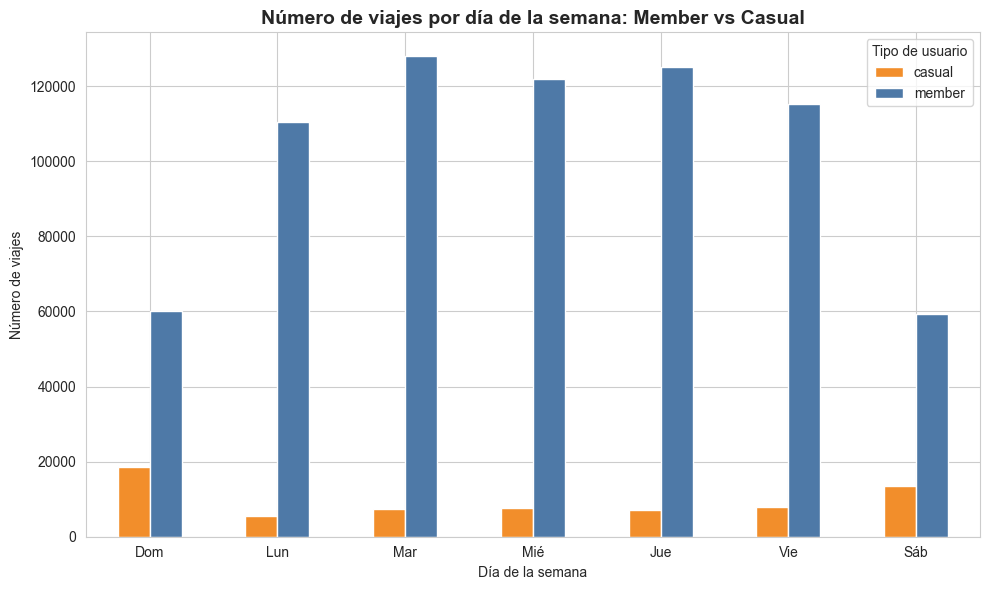

In [39]:
# Crear carpeta de salida para las figuras si no existe
os.makedirs('outputs/figures', exist_ok=True)

fig, ax = plt.subplots()
rides_by_day_pivot.rename(index=day_names).plot(kind='bar', ax=ax, color=['#F28E2B', '#4E79A7'])
ax.set_title('Número de viajes por día de la semana: Member vs Casual', fontsize=14, fontweight='bold')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Número de viajes')
ax.legend(title='Tipo de usuario')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/figures/viajes_por_dia.png', dpi=150)
plt.show()

Gráfica 2. Duración promedio de viaje por día de la semana

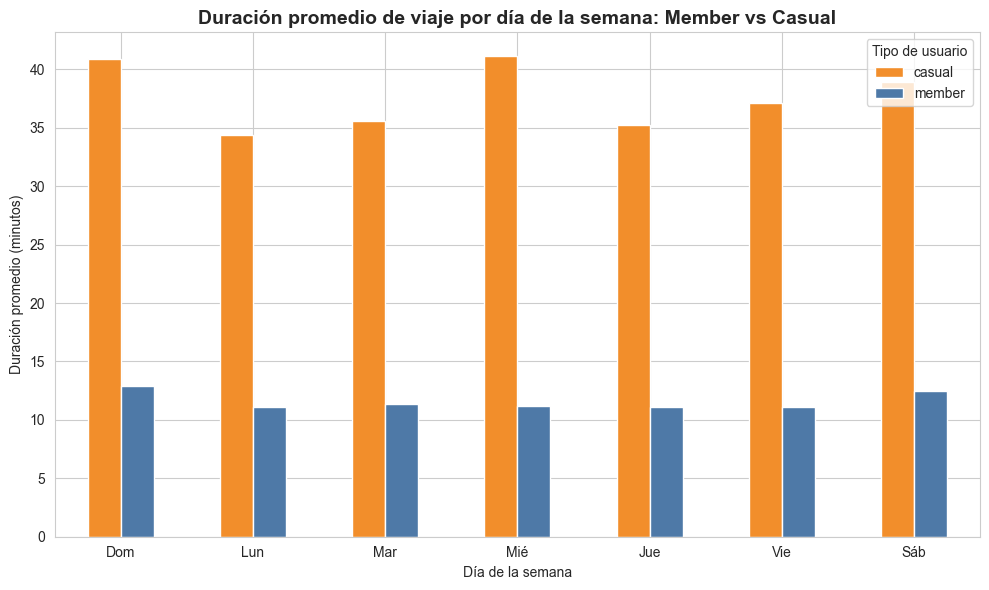

In [41]:
fig, ax = plt.subplots()
avg_duration_pivot.rename(index=day_names).plot(kind='bar', ax=ax, color=['#F28E2B', '#4E79A7'])
ax.set_title('Duración promedio de viaje por día de la semana: Member vs Casual', fontsize=14, fontweight='bold')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Duración promedio (minutos)')
ax.legend(title='Tipo de usuario')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/figures/duracion_por_dia.png', dpi=150)
plt.show()

Gráfica 3. Número de viajes por hora del día

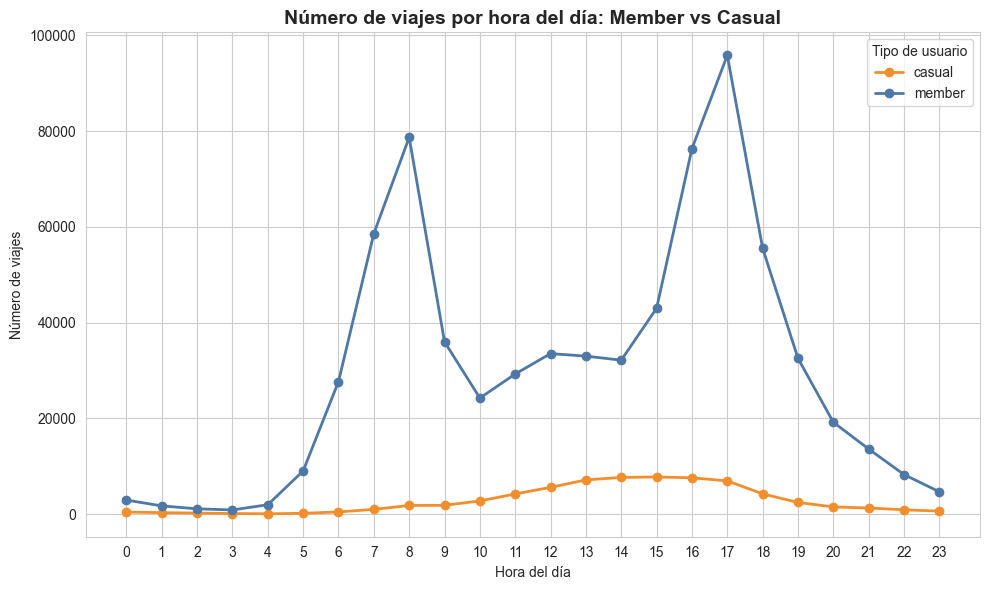

In [42]:
fig, ax = plt.subplots()
rides_by_hour.plot(kind='line', ax=ax, marker='o', color=['#F28E2B', '#4E79A7'], linewidth=2)
ax.set_title('Número de viajes por hora del día: Member vs Casual', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Número de viajes')
ax.set_xticks(range(0, 24))
ax.legend(title='Tipo de usuario')
plt.tight_layout()
plt.savefig('outputs/figures/viajes_por_hora.png', dpi=150)
plt.show()

Gráfica 4. Distribución de duración de viaje (boxplot, con escala controlada)

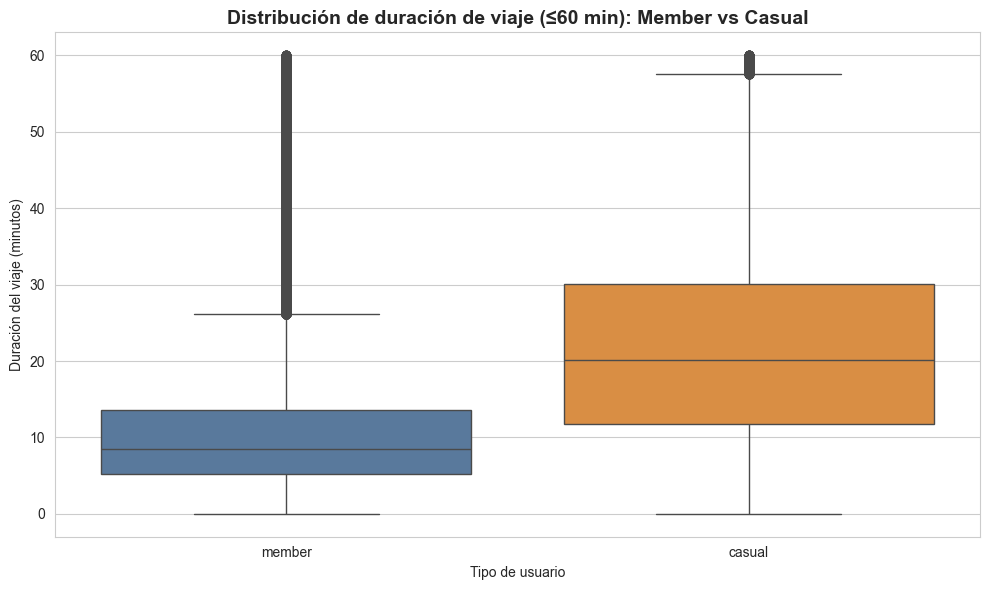

In [44]:
fig, ax = plt.subplots()
sns.boxplot(
    data=all_trips_clean[all_trips_clean['ride_length'] <= 60],
    x='member_casual', y='ride_length', hue='member_casual', legend=False, ax=ax,
    palette={'member': '#4E79A7', 'casual': '#F28E2B'}
)
ax.set_title('Distribución de duración de viaje (≤60 min): Member vs Casual', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de usuario')
ax.set_ylabel('Duración del viaje (minutos)')
plt.tight_layout()
plt.savefig('outputs/figures/distribucion_duracion.png', dpi=150)
plt.show()

## 5. Share (Compartir) — Visualizaciones

Se generaron 4 visualizaciones clave para comunicar los hallazgos al equipo ejecutivo:

1. **Número de viajes por día de la semana** — muestra el contraste entre el patrón de 
   uso entre semana de los members y el patrón de fin de semana de los casual riders.
2. **Duración promedio por día de la semana** — evidencia que los casual riders tienen 
   viajes más largos todos los días, con picos los fines de semana.
3. **Número de viajes por hora del día** — la gráfica más reveladora: expone los dos 
   picos de "hora pico" (commute) de los members, ausentes en los casual riders.
4. **Distribución de duración de viaje (boxplot)** — visualiza la mayor dispersión y 
   mediana más alta de los casual riders frente a la consistencia de los members.

Todas las figuras se guardaron en `outputs/figures/` en formato PNG a 150 dpi.

## 6. Act (Actuar) — Recomendaciones

**Recomendación 1: Campaña de "conversión de fin de semana" con incentivo a la 
membresía anual.** Los casual riders concentran su actividad los fines de semana 
(sábado y domingo son sus días de mayor volumen y duración). Se recomienda una campaña 
dirigida específicamente a usuarios que rentan en fin de semana, ofreciendo una prueba 
gratuita o descuento en la primera membresía anual, presentada justo al finalizar un 
viaje de fin de semana (vía notificación push o correo).

**Recomendación 2: Membresía flexible o "fin de semana" como puente hacia la anual.** 
Dado que la duración de viaje de casual riders es consistentemente más alta (mediana 
23 min vs 8.5 min de members) y concentrada en tardes/fines de semana, un plan 
intermedio (ej. membresía de fin de semana o de bajo compromiso) podría capturar a 
usuarios que aún no están listos para el compromiso anual completo, sirviendo como 
puente de conversión.

**Recomendación 3: Comunicación dirigida a "casi members".** Identificar y dar 
seguimiento a casual riders con alta frecuencia de uso (aunque sea solo en fin de 
semana) mediante campañas de email/app basadas en su propio historial de ahorro 
potencial (ej. "Ya gastaste $X en pases individuales este mes — con la membresía 
anual habrías ahorrado $Y"), aprovechando que ya conocen y usan el servicio.

**Próximos pasos sugeridos:**
- Ampliar el análisis a los 12 meses completos (no solo Q1) para confirmar si el 
  patrón estacional afecta las conclusiones.
- Investigar estaciones específicas con mayor concentración de casual riders para 
  focalizar geográficamente las campañas.
- Diseñar un test A/B de las ofertas propuestas antes de un rollout completo.